In [1]:
!nvidia-smi

Fri Oct  9 05:05:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import cuda

device = cuda.get_current_device()

print("Device Name:", device.name)
print("Compute Capability:", device.compute_capability)
print("Multiprocessor Count:",
      getattr(device, "MULTIPROCESSOR_COUNT", "N/A"))
print("Max Threads Per Block:",
      device.MAX_THREADS_PER_BLOCK)
print("Max Block Dimensions:",
      device.MAX_BLOCK_DIM_X,
      device.MAX_BLOCK_DIM_Y,
      device.MAX_BLOCK_DIM_Z)
print("Warp Size:", device.WARP_SIZE)

Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count: 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024 1024 64
Warp Size: 32


In [8]:
import numpy as np
import time
from numba import cuda

# CPU: последовательное вычисление
def double_cpu_pure(arr):
    out = np.empty_like(arr)

    for i in range(len(arr)):
        out[i] = arr[i] * 2.0

    return out

# GPU: параллельное вычисление
@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)

    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

In [9]:
def benchmark_run(N, student_id_seed=1234):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)

    # CPU
    if N <= 1_000_000:
        t0 = time.perf_counter()
        cpu_result = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000
    else:
        cpu_time_ms = float("nan")

    # GPU configuration
    threads_per_block = 256
    blocks_per_grid = (
        N + threads_per_block - 1
    ) // threads_per_block

    # Warmup
    d_warmup = cuda.to_device(
        np.ones(10, dtype=np.float32)
    )
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()

    # GPU Total
    t0 = time.perf_counter()

    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)

    double_gpu_kernel[
        blocks_per_grid, threads_per_block
    ](d_in, d_out)

    h_out = d_out.copy_to_host()
    cuda.synchronize()

    gpu_total_ms = (
        time.perf_counter() - t0
    ) * 1000

    # GPU Kernel Only
    t0 = time.perf_counter()

    double_gpu_kernel[
        blocks_per_grid, threads_per_block
    ](d_in, d_out)

    cuda.synchronize()

    gpu_compute_ms = (
        time.perf_counter() - t0
    ) * 1000

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms

In [10]:
sizes = [
    100,
    1000,
    10000,
    100000,
    1000000,
    5000000,
    10000000
]

results = []

print("N | CPU ms | GPU Total ms | GPU Kernel ms | Winner")

for N in sizes:
    cpu, gpu_total, gpu_kernel = benchmark_run(N)

    if np.isnan(cpu):
        winner = "N/A"
    elif cpu < gpu_total:
        winner = "CPU"
    else:
        winner = "GPU"

    results.append((N, cpu, gpu_total, gpu_kernel, winner))

    print(
        f"{N} | {cpu:.4f} | {gpu_total:.4f} | "
        f"{gpu_kernel:.4f} | {winner}"
    )

N | CPU ms | GPU Total ms | GPU Kernel ms | Winner


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


100 | 0.0696 | 1.3856 | 0.1190 | CPU
1000 | 0.2843 | 0.5875 | 0.1312 | CPU
10000 | 2.6436 | 0.5491 | 0.0623 | GPU
100000 | 25.3902 | 0.7065 | 0.0672 | GPU
1000000 | 259.3307 | 4.8293 | 0.1145 | GPU
5000000 | nan | 13.5562 | 0.2962 | N/A
10000000 | nan | 25.2826 | 0.4537 | N/A


In [11]:
@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = 4

print("Launching defective kernel...")

defective_kernel[
    blocks_per_grid, threads_per_block
](d_arr)

cuda.synchronize()

h_result = d_arr.copy_to_host()

print("Elements processed:", len(h_result))
print("Last element:", h_result[-1])

Launching defective kernel...
Elements processed: 1000
Last element: 999.0


In [12]:
@cuda.jit
def inspect_threads_kernel(
    log_block, log_thread,
    log_global, log_active, N
):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)

    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (
    N + threads_per_block - 1
) // threads_per_block

total_threads = blocks_per_grid * threads_per_block

log_b = cuda.device_array(total_threads, dtype=np.int32)
log_t = cuda.device_array(total_threads, dtype=np.int32)
log_g = cuda.device_array(total_threads, dtype=np.int32)
log_a = cuda.device_array(total_threads, dtype=np.int32)

inspect_threads_kernel[
    blocks_per_grid, threads_per_block
](log_b, log_t, log_g, log_a, N)

cuda.synchronize()

# Copy results from GPU to CPU
host_b = log_b.copy_to_host()
host_t = log_t.copy_to_host()
host_g = log_g.copy_to_host()
host_a = log_a.copy_to_host()

for i in range(32, 40):
    status = "ACTIVE" if host_a[i] == 1 else "IDLE (GUARDED)"

    print(
        f"Global: {host_g[i]} | "
        f"Block: {host_b[i]} | "
        f"Thread: {host_t[i]} | {status}"
    )

Global: 32 | Block: 4 | Thread: 0 | ACTIVE
Global: 33 | Block: 4 | Thread: 1 | ACTIVE
Global: 34 | Block: 4 | Thread: 2 | ACTIVE
Global: 35 | Block: 4 | Thread: 3 | ACTIVE
Global: 36 | Block: 4 | Thread: 4 | ACTIVE
Global: 37 | Block: 4 | Thread: 5 | IDLE (GUARDED)
Global: 38 | Block: 4 | Thread: 6 | IDLE (GUARDED)
Global: 39 | Block: 4 | Thread: 7 | IDLE (GUARDED)


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [13]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)

    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]


@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)

    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])

In [14]:
N = 50000

h_arr = np.ones(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads = 256
blocks = (N + threads - 1) // threads

print("Expected Sum: 50000.0")

for trial in range(1, 6):
    d_total = cuda.to_device(
        np.zeros(1, dtype=np.float32)
    )

    naive_sum_kernel[blocks, threads](d_arr, d_total)
    cuda.synchronize()

    actual = float(d_total.copy_to_host()[0])
    deviation = 50000.0 - actual

    print(
        f"Trial {trial}: "
        f"Naive = {actual:.1f}, "
        f"Lost Updates = {deviation:.1f}"
    )

Expected Sum: 50000.0
Trial 1: Naive = 2.0, Lost Updates = 49998.0
Trial 2: Naive = 2.0, Lost Updates = 49998.0
Trial 3: Naive = 2.0, Lost Updates = 49998.0
Trial 4: Naive = 2.0, Lost Updates = 49998.0
Trial 5: Naive = 2.0, Lost Updates = 49998.0


In [15]:
# Prepare GPU memory
d_total = cuda.to_device(np.zeros(1, dtype=np.float32))

# Warm up kernels before timing
naive_sum_kernel[blocks, threads](d_arr, d_total)
cuda.synchronize()

d_total.copy_to_device(np.zeros(1, dtype=np.float32))
atomic_sum_kernel[blocks, threads](d_arr, d_total)
cuda.synchronize()

# Naive timing
d_total.copy_to_device(np.zeros(1, dtype=np.float32))
cuda.synchronize()

t0 = time.perf_counter()
naive_sum_kernel[blocks, threads](d_arr, d_total)
cuda.synchronize()
naive_ms = (time.perf_counter() - t0) * 1000

# Atomic timing
d_total.copy_to_device(np.zeros(1, dtype=np.float32))
cuda.synchronize()

t0 = time.perf_counter()
atomic_sum_kernel[blocks, threads](d_arr, d_total)
cuda.synchronize()
atomic_ms = (time.perf_counter() - t0) * 1000

atomic_result = d_total.copy_to_host()[0]

print("Atomic Sum Output:", atomic_result)
print("Naive Kernel Time:", round(naive_ms, 4), "ms")
print("Atomic Kernel Time:", round(atomic_ms, 4), "ms")

Atomic Sum Output: 50000.0
Naive Kernel Time: 0.3344 ms
Atomic Kernel Time: 0.4504 ms


Grid Dimensions: (64, 64)
Total Blocks: 4096
Matrix Shape: (1024, 1024)
Center Value: 1.0
Corner Value: 0.0


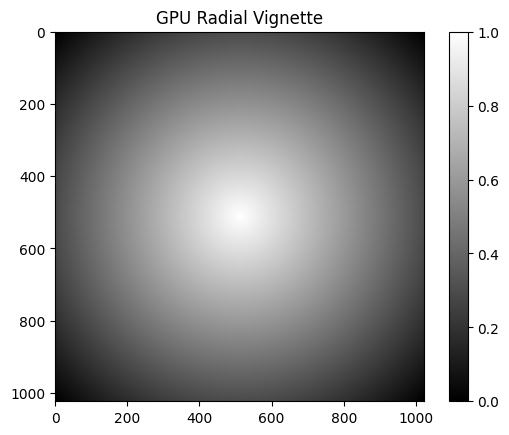

In [16]:
import math
import matplotlib.pyplot as plt

@cuda.jit
def radial_vignette_2d(
    d_canvas, width, height, center_x, center_y
):
    x, y = cuda.grid(2)

    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)

        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(
            float(center_x**2 + center_y**2)
        )

        intensity = 1.0 - (dist / max_dist)

        if intensity < 0.0:
            intensity = 0.0

        d_canvas[y, x] = intensity


WIDTH, HEIGHT = 1024, 1024

canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)

threads_2d = (16, 16)

blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)

radial_vignette_2d[blocks_2d, threads_2d](
    d_canvas,
    WIDTH,
    HEIGHT,
    WIDTH // 2,
    HEIGHT // 2
)

cuda.synchronize()

result_canvas = d_canvas.copy_to_host()

print("Grid Dimensions:", blocks_2d)
print("Total Blocks:", blocks_2d[0] * blocks_2d[1])
print("Matrix Shape:", result_canvas.shape)
print("Center Value:", result_canvas[512, 512])
print("Corner Value:", result_canvas[0, 0])

plt.imshow(result_canvas, cmap="gray")
plt.title("GPU Radial Vignette")
plt.colorbar()
plt.show()

In [24]:
import hashlib
from numba import cuda

def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()

    # Student ID
    h.update(student_id_str.strip().encode("utf-8"))

    # GPU Name (FIXED)
    gpu_name = cuda.get_current_device().name
    if isinstance(gpu_name, str):
        gpu_name = gpu_name.encode("utf-8")
    h.update(gpu_name)

    # GPU computation results
    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())

    # Crossover point
    h.update(str(exp_table_crossover).encode("utf-8"))

    digest = h.hexdigest()[:16].upper()

    print("=" * 60)
    print("OFFICIAL VERIFICATION CHECKSUM TOKEN:", digest)
    print("=" * 60)

    return digest

In [25]:
STUDENT_ID = "230103027"

# Replace with your measured crossover from Section 2
CROSSOVER_N = 100000

generate_lab_checksum(
    STUDENT_ID,
    d_canvas,
    CROSSOVER_N
)

OFFICIAL VERIFICATION CHECKSUM TOKEN: 29E2C2D5B6647523


'29E2C2D5B6647523'